## Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap

PROC = "/content/drive/MyDrive/Machine_learning_project/Data/Processed"
VIZ  = "/content/drive/MyDrive/Machine_learning_project/Data/Visualization"
os.makedirs(VIZ, exist_ok=True)

# ---------- global style ----------
mpl.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.6,
    "legend.frameon": False,
})

# consistent colours: one per modality, used everywhere
C = {
    "tabular":            "#1f6feb",   # blue
    "text":               "#1f9d57",   # green
    "image":              "#d98a00",   # amber
    "tabular+text":       "#5a4fcf",
    "tabular+image":      "#c2410c",
    "text+image":         "#0e7490",
    "tabular+text+image": "#7c3aed",   # purple = full fusion
    "STACKING":           "#be185d",   # pink = stacking
}
GREY = "#94a3b8"

def save(fig, name):
    """Save every figure as PNG (slides) + PDF (report)."""
    fig.savefig(f"{VIZ}/{name}.png")
    fig.savefig(f"{VIZ}/{name}.pdf")
    print(f"  saved {name}.png / .pdf")

## Load results

In [3]:
res = pd.read_csv(f"{PROC}/model_results.csv")
pred = np.load(f"{PROC}/predictions.npz")
y_test = pred["y_test"]

FEAT_ORDER = ["tabular", "text", "image",
              "tabular+text", "tabular+image", "text+image",
              "tabular+text+image"]
MODEL_ORDER = ["Dummy", "kNN", "Ridge", "RandomForest", "MLP", "XGBoost", "LightGBM"]

grid = res[res["features"].isin(FEAT_ORDER)]
stack = res[res["features"].str.startswith("STACKING")]

print(f"{len(res)} runs | best: {res.iloc[0]['features']} + {res.iloc[0]['model']} "
      f"(R2 = {res.iloc[0]['R2']:.4f})")
res.head(5)[["features", "model", "R2", "RMSE_log", "MAE_usd"]]

50 runs | best: tabular+text + LightGBM (R2 = 0.7530)


,features,model,R2,RMSE_log,MAE_usd
0,tabular+text,LightGBM,0.7530,0.2867,42.2735
1,STACKING (tab+text+img),Ridge-meta,0.7529,0.2867,41.8523
2,tabular+text,XGBoost,0.7520,0.2872,41.8821
3,tabular+text+image,LightGBM,0.7514,0.2876,42.1275
4,tabular+text+image,XGBoost,0.7496,0.2887,42.3821


## Figure 1 — The results grid (heatmap)

  saved fig1_results_heatmap.png / .pdf


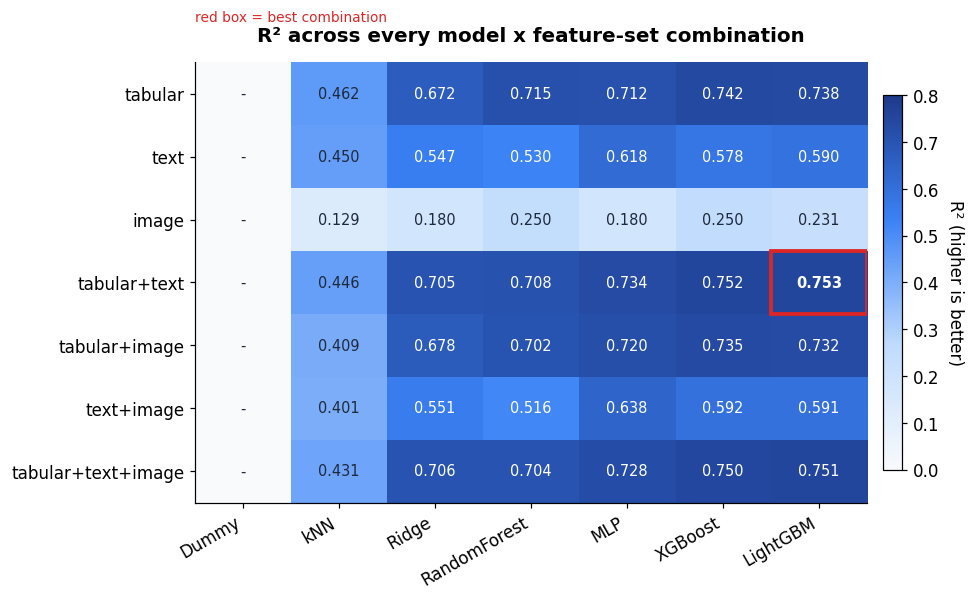

In [4]:
piv = grid.pivot(index="features", columns="model", values="R2")
piv = piv.reindex(index=FEAT_ORDER, columns=MODEL_ORDER)

fig, ax = plt.subplots(figsize=(9.5, 5.2))

cmap = LinearSegmentedColormap.from_list("r2", ["#f8fafc", "#bfdbfe", "#3b82f6", "#1e3a8a"])
im = ax.imshow(piv.values, cmap=cmap, vmin=0, vmax=0.8, aspect="auto")

ax.set_xticks(range(len(piv.columns)), piv.columns, rotation=30, ha="right")
ax.set_yticks(range(len(piv.index)), piv.index)

# annotate every cell; highlight the best
best = np.nanmax(piv.values)
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        v = piv.values[i, j]
        if np.isnan(v):
            continue
        txt = "-" if v < 0 else f"{v:.3f}"
        ax.text(j, i, txt, ha="center", va="center", fontsize=9.5,
                color="white" if v > 0.5 else "#1e293b",
                fontweight="bold" if v == best else "normal")
        if v == best:
            ax.add_patch(plt.Rectangle((j-.5, i-.5), 1, 1, fill=False,
                                       edgecolor="#dc2626", lw=2.5))

ax.set_title("R² across every model x feature-set combination", pad=14)
ax.set_xlabel("")
ax.set_ylabel("")
ax.grid(False)
cb = fig.colorbar(im, ax=ax, shrink=0.85, pad=0.02)
cb.set_label("R² (higher is better)", rotation=270, labelpad=16)
ax.text(0, -1.15, "red box = best combination", fontsize=9, color="#dc2626",
        transform=ax.get_yaxis_transform(), clip_on=False)

save(fig, "fig1_results_heatmap")
plt.show()

## Figure 2 — The modality ablation

The core question of the project: **does each modality earn its place?**
Best model per feature set, so nothing is hidden by a weak learner.

  saved fig2_modality_ablation.png / .pdf


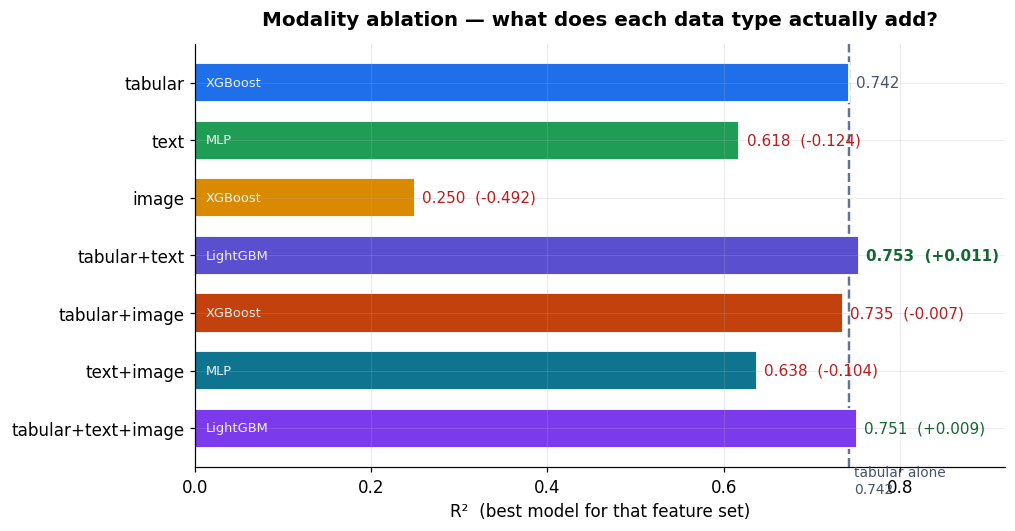


Delta vs tabular alone:
  tabular              0.7420   +0.0000
  text                 0.6178   -0.1242
  image                0.2502   -0.4918
  tabular+text         0.7530   +0.0110
  tabular+image        0.7348   -0.0072
  text+image           0.6377   -0.1043
  tabular+text+image   0.7514   +0.0094


In [5]:
bestper = (grid.loc[grid.groupby("features")["R2"].idxmax()]
              .set_index("features").reindex(FEAT_ORDER))

fig, ax = plt.subplots(figsize=(9.5, 5))

vals   = bestper["R2"].values
labels = bestper.index
colors = [C[f] for f in labels]

bars = ax.barh(range(len(labels)), vals, color=colors, height=0.68,
               edgecolor="white", linewidth=1.2)

# reference line: tabular alone (the baseline everything must beat)
tab_r2 = bestper.loc["tabular", "R2"]
ax.axvline(tab_r2, color="#64748b", ls="--", lw=1.6, zorder=0)
ax.text(tab_r2 + .006, len(labels) - 0.35, f"tabular alone\n{tab_r2:.3f}",
        fontsize=9, color="#475569", va="top")

for i, (v, m) in enumerate(zip(vals, bestper["model"])):
    delta = v - tab_r2
    tag = "" if labels[i] == "tabular" else f"  ({delta:+.3f})"
    ax.text(v + .008, i, f"{v:.3f}{tag}", va="center", fontsize=10,
            fontweight="bold" if v == vals.max() else "normal",
            color="#166534" if delta > 0.005 else ("#b91c1c" if delta < -0.005 else "#475569"))
    ax.text(.012, i, m, va="center", fontsize=8.5, color="white", alpha=.9)

ax.set_yticks(range(len(labels)), labels)
ax.set_xlim(0, max(vals) * 1.22)
ax.set_xlabel("R²  (best model for that feature set)")
ax.set_title("Modality ablation — what does each data type actually add?", pad=12)
ax.invert_yaxis()

save(fig, "fig2_modality_ablation")
plt.show()

print("\nDelta vs tabular alone:")
for f in FEAT_ORDER:
    d = bestper.loc[f, "R2"] - tab_r2
    print(f"  {f:<20} {bestper.loc[f,'R2']:.4f}   {d:+.4f}")

## Figure 3 — Model families compared

Do different algorithms agree? Convergence across families means the ceiling
is a property of the **data**, not the model.

  saved fig3_model_families.png / .pdf


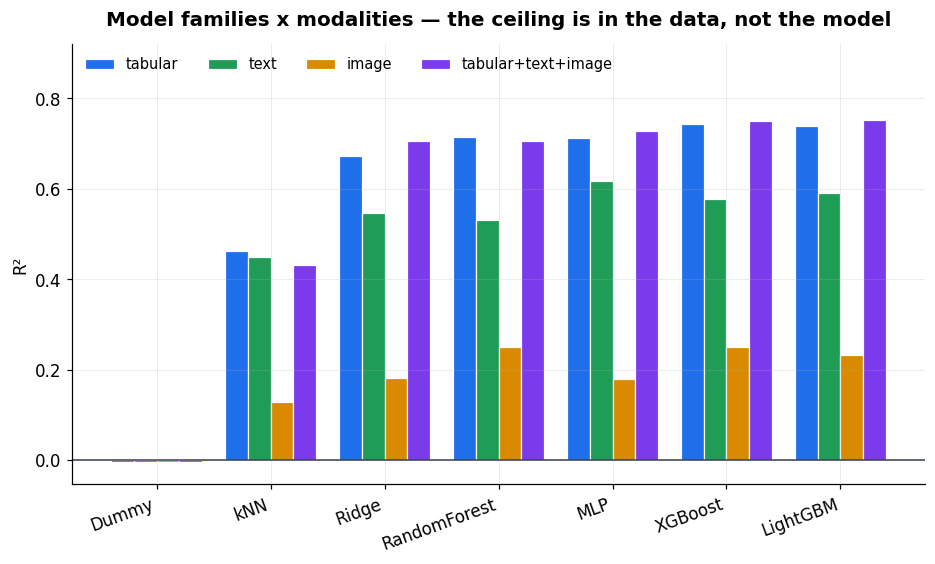

In [6]:
fig, ax = plt.subplots(figsize=(10, 5.2))

sub = grid[grid["features"].isin(["tabular", "text", "image", "tabular+text+image"])]
piv2 = sub.pivot(index="model", columns="features", values="R2").reindex(MODEL_ORDER)

x = np.arange(len(piv2.index))
cols = ["tabular", "text", "image", "tabular+text+image"]
w = 0.2

for k, c in enumerate(cols):
    ax.bar(x + (k - 1.5) * w, piv2[c].values, w, label=c,
           color=C[c], edgecolor="white", linewidth=0.8)

ax.axhline(0, color="#334155", lw=1)
ax.set_xticks(x, piv2.index, rotation=20, ha="right")
ax.set_ylabel("R²")
ax.set_title("Model families x modalities — the ceiling is in the data, not the model", pad=12)
ax.legend(ncol=4, loc="upper left", fontsize=9.5)
ax.set_ylim(min(-0.05, piv2.values.min() - 0.05), 0.92)

save(fig, "fig3_model_families")
plt.show()

## Figure 4 — Predicted vs actual (best model)

Where does the model succeed, and where does it break down?

  saved fig4_predicted_vs_actual.png / .pdf


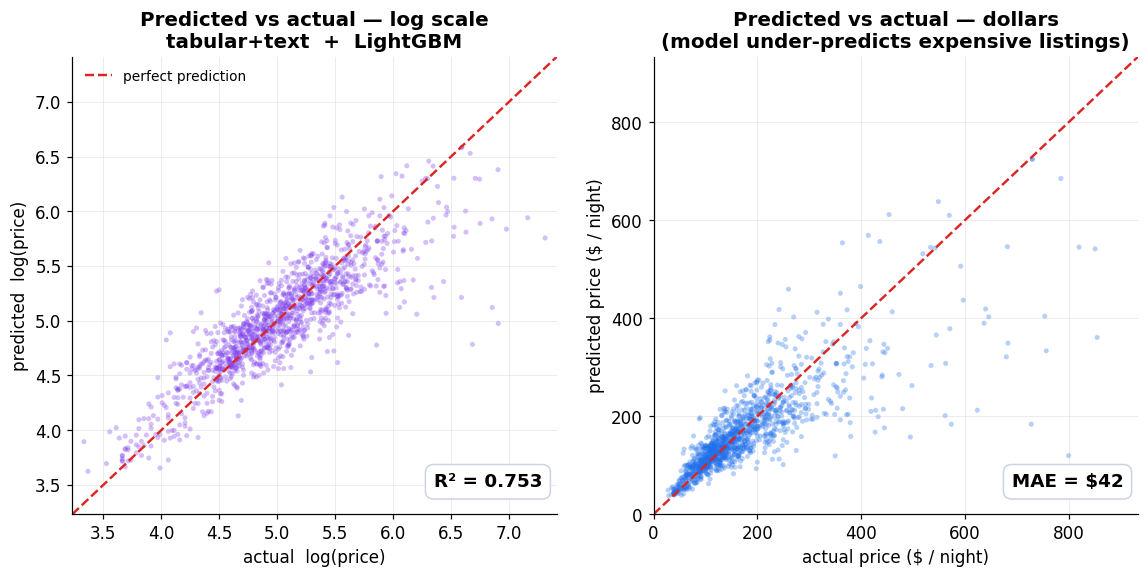

In [7]:
best_key = f"{res.iloc[0]['features']}|{res.iloc[0]['model']}"
yp = pred[best_key]

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.4))

# ---- (a) log scale ----
ax = axes[0]
ax.scatter(y_test, yp, s=11, alpha=.32, color=C["tabular+text+image"],
           edgecolors="none", rasterized=True)
lo, hi = y_test.min() - .1, y_test.max() + .1
ax.plot([lo, hi], [lo, hi], color="#dc2626", lw=1.6, ls="--", label="perfect prediction")
ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
ax.set_xlabel("actual  log(price)")
ax.set_ylabel("predicted  log(price)")
ax.set_title(f"Predicted vs actual — log scale\n{best_key.replace('|', '  +  ')}")
ax.legend(loc="upper left", fontsize=9)
r2 = res.iloc[0]["R2"]
ax.text(.97, .06, f"R² = {r2:.3f}", transform=ax.transAxes, ha="right",
        fontsize=12, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.45", fc="white", ec="#cbd5e1"))

# ---- (b) dollar scale ----
ax = axes[1]
at, pt = np.exp(y_test), np.exp(yp)
ax.scatter(at, pt, s=11, alpha=.32, color=C["tabular"], edgecolors="none", rasterized=True)
m = max(at.max(), pt.max())
ax.plot([0, m], [0, m], color="#dc2626", lw=1.6, ls="--")
ax.set_xlim(0, np.percentile(at, 99.5)); ax.set_ylim(0, np.percentile(at, 99.5))
ax.set_xlabel("actual price ($ / night)")
ax.set_ylabel("predicted price ($ / night)")
ax.set_title("Predicted vs actual — dollars\n(model under-predicts expensive listings)")
mae = res.iloc[0]["MAE_usd"]
ax.text(.97, .06, f"MAE = ${mae:.0f}", transform=ax.transAxes, ha="right",
        fontsize=12, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.45", fc="white", ec="#cbd5e1"))

save(fig, "fig4_predicted_vs_actual")
plt.show()

## Figure 5 — Residual analysis

Are the errors well-behaved? Systematic structure in residuals means the model is missing something.

  saved fig5_residuals.png / .pdf


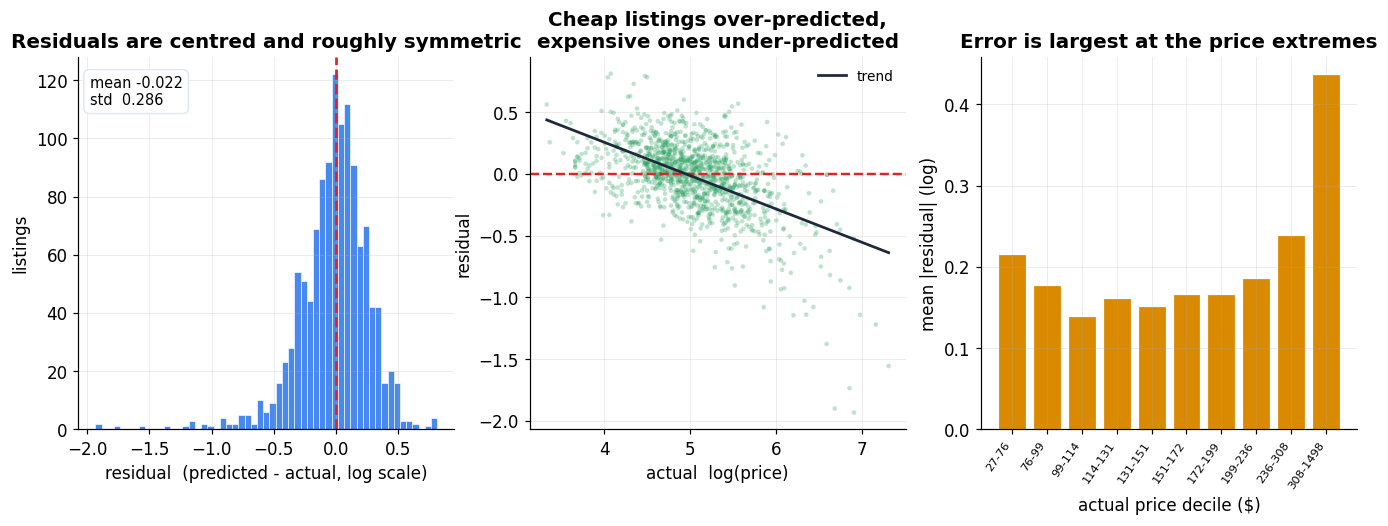

In [8]:
resid = yp - y_test

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))

# (a) residual distribution
ax = axes[0]
ax.hist(resid, bins=55, color=C["tabular"], alpha=.82, edgecolor="white", linewidth=.5)
ax.axvline(0, color="#dc2626", lw=1.8, ls="--")
ax.set_xlabel("residual  (predicted - actual, log scale)")
ax.set_ylabel("listings")
ax.set_title("Residuals are centred and roughly symmetric")
ax.text(.03, .95, f"mean {resid.mean():+.3f}\nstd  {resid.std():.3f}",
        transform=ax.transAxes, va="top", fontsize=9.5,
        bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="#e2e8f0"))

# (b) residual vs actual -> reveals shrinkage toward the mean
ax = axes[1]
ax.scatter(y_test, resid, s=9, alpha=.28, color=C["text"], edgecolors="none", rasterized=True)
ax.axhline(0, color="#dc2626", lw=1.6, ls="--")
z = np.polyfit(y_test, resid, 1)
xs = np.linspace(y_test.min(), y_test.max(), 50)
ax.plot(xs, np.poly1d(z)(xs), color="#1e293b", lw=1.8, label="trend")
ax.set_xlabel("actual  log(price)")
ax.set_ylabel("residual")
ax.set_title("Cheap listings over-predicted,\nexpensive ones under-predicted")
ax.legend(fontsize=9)

# (c) error by price decile -> where does the model actually fail?
ax = axes[2]
dec = pd.qcut(np.exp(y_test), 10, labels=False)
mae_dec = [np.abs(resid[dec == d]).mean() for d in range(10)]
edges = pd.qcut(np.exp(y_test), 10).categories
ax.bar(range(10), mae_dec, color=C["image"], edgecolor="white", linewidth=.8)
ax.set_xticks(range(10), [f"{int(e.left)}-{int(e.right)}" for e in edges],
              rotation=55, ha="right", fontsize=7.5)
ax.set_xlabel("actual price decile ($)")
ax.set_ylabel("mean |residual| (log)")
ax.set_title("Error is largest at the price extremes")

save(fig, "fig5_residuals")
plt.show()

## Figure 6 — Fusion strategies compared

The two ways of combining modalities (features vs predictions), against the
single-modality baselines.

  saved fig6_fusion_strategies.png / .pdf


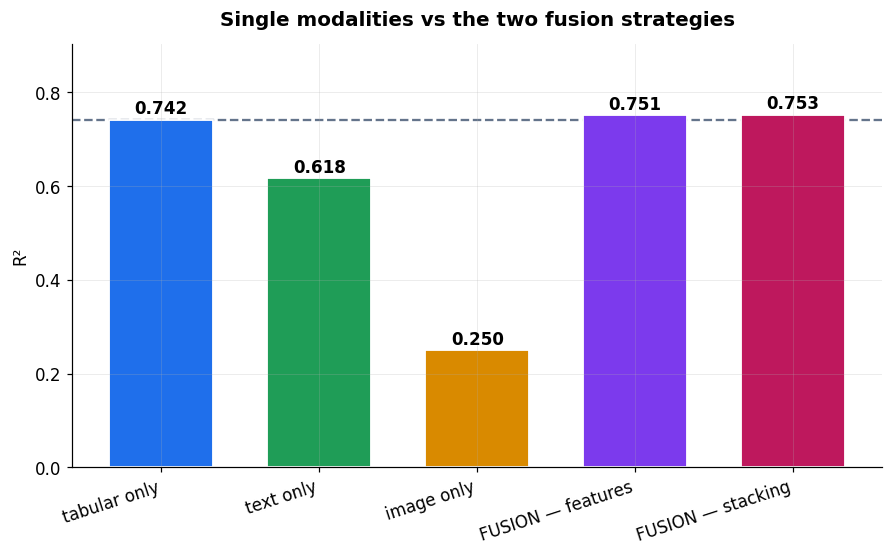

In [9]:
fig, ax = plt.subplots(figsize=(9.5, 5))

rows = [
    ("tabular only",            bestper.loc["tabular", "R2"],            C["tabular"]),
    ("text only",               bestper.loc["text", "R2"],               C["text"]),
    ("image only",              bestper.loc["image", "R2"],              C["image"]),
    ("FUSION — features",       bestper.loc["tabular+text+image", "R2"], C["tabular+text+image"]),
    ("FUSION — stacking",       float(stack["R2"].iloc[0]),              C["STACKING"]),
]
names  = [r[0] for r in rows]
vals   = [r[1] for r in rows]
colors = [r[2] for r in rows]

bars = ax.bar(range(len(rows)), vals, color=colors, width=.66,
              edgecolor="white", linewidth=1.2)
for i, v in enumerate(vals):
    ax.text(i, v + .012, f"{v:.3f}", ha="center", fontsize=11, fontweight="bold")

ax.axhline(bestper.loc["tabular", "R2"], color="#64748b", ls="--", lw=1.5, zorder=0)
ax.set_xticks(range(len(rows)), names, rotation=18, ha="right")
ax.set_ylabel("R²")
ax.set_ylim(0, max(vals) * 1.2)
ax.set_title("Single modalities vs the two fusion strategies", pad=12)

save(fig, "fig6_fusion_strategies")
plt.show()

## Figure 7 — Metric comparison

R² is not the whole story. Different metrics rank models differently, and the dollar-scale errors are what a human actually understands.

  saved fig7_metric_comparison.png / .pdf


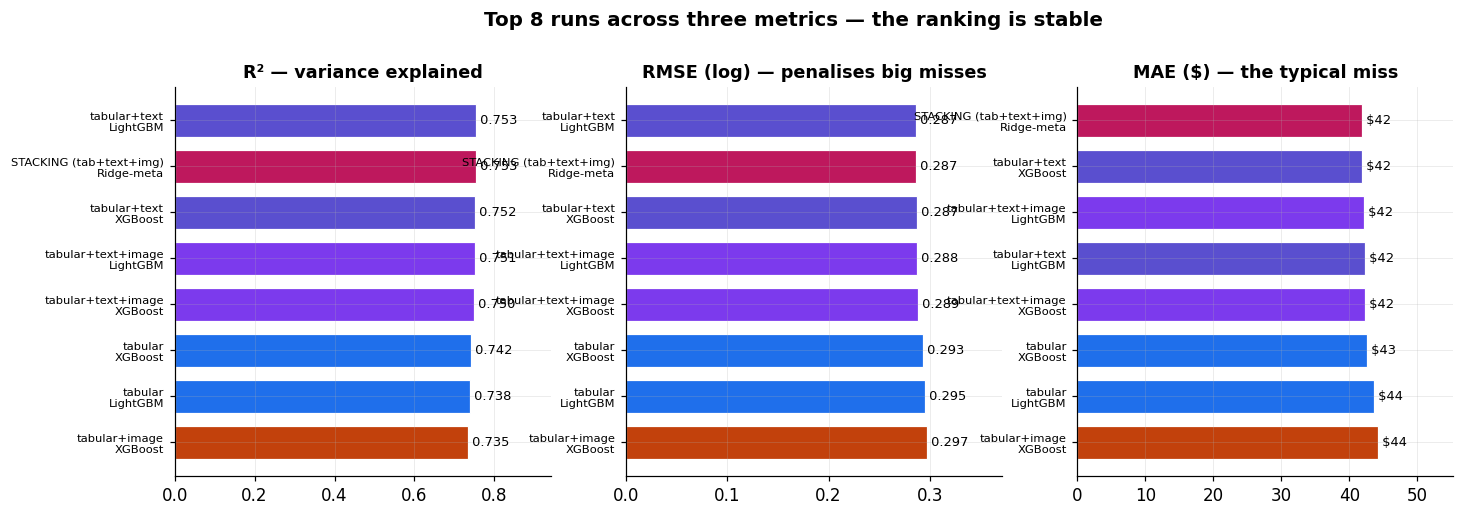

In [10]:
top = res.head(8).copy()
top["label"] = top["features"] + "\n" + top["model"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))

for ax, (col, title, unit) in zip(axes, [
    ("R2",       "R² — variance explained",  ""),
    ("RMSE_log", "RMSE (log) — penalises big misses", ""),
    ("MAE_usd",  "MAE ($) — the typical miss", "$"),
]):
    order = top.sort_values(col, ascending=(col != "R2"))
    cols  = [C.get(f.split("\n")[0], GREY) if not f.startswith("STACKING") else C["STACKING"]
             for f in order["label"]]
    ax.barh(range(len(order)), order[col].values, color=cols,
            edgecolor="white", linewidth=.8, height=.7)
    ax.set_yticks(range(len(order)), order["label"], fontsize=7.5)
    ax.set_title(title, fontsize=11.5)
    ax.invert_yaxis()
    for i, v in enumerate(order[col].values):
        ax.text(v, i, f" {unit}{v:.3f}" if not unit else f" {unit}{v:.0f}",
                va="center", fontsize=8.5)
    ax.set_xlim(0, order[col].max() * 1.25)

fig.suptitle("Top 8 runs across three metrics — the ranking is stable",
             fontsize=13, fontweight="bold", y=1.03)

save(fig, "fig7_metric_comparison")
plt.show()

## Figure 8 — Compute cost vs accuracy

Is the expensive model worth it? A practical trade-off worth showing.

  saved fig8_cost_vs_accuracy.png / .pdf


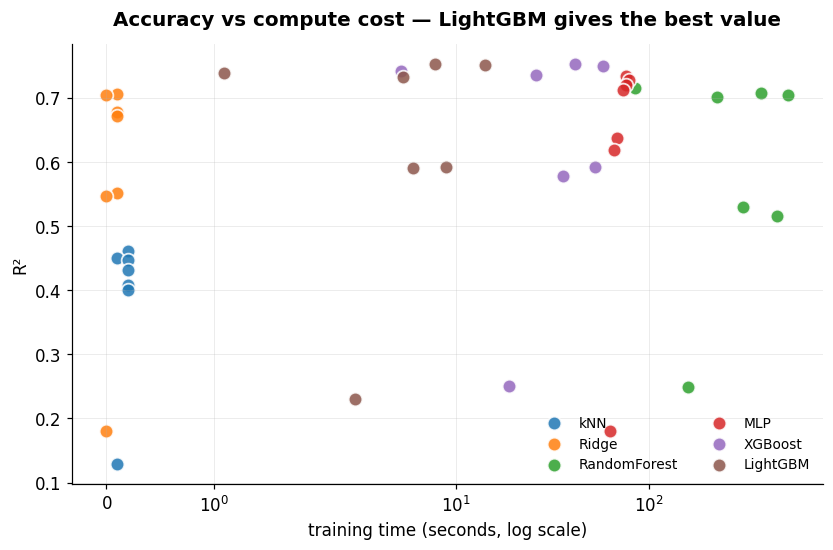

In [11]:
fig, ax = plt.subplots(figsize=(8.8, 5.2))

g = grid[grid["model"] != "Dummy"]
for model in [m for m in MODEL_ORDER if m != "Dummy"]:
    s = g[g["model"] == model]
    ax.scatter(s["fit_seconds"], s["R2"], s=80, alpha=.85, label=model,
               edgecolors="white", linewidth=1.2)

ax.set_xscale("symlog")
ax.set_xlabel("training time (seconds, log scale)")
ax.set_ylabel("R²")
ax.set_title("Accuracy vs compute cost — LightGBM gives the best value", pad=12)
ax.legend(ncol=2, fontsize=9, loc="lower right")

save(fig, "fig8_cost_vs_accuracy")
plt.show()

## Summary table for the slides

In [12]:
summary = (bestper.reset_index()[["features", "model", "R2", "RMSE_log", "MAE_usd", "MAPE"]]
             .rename(columns={"R2": "R²", "RMSE_log": "RMSE (log)",
                              "MAE_usd": "MAE ($)", "MAPE": "MAPE"}))

st = stack.iloc[0]
summary.loc[len(summary)] = ["STACKING", "Ridge-meta", st["R2"],
                             st["RMSE_log"], st["MAE_usd"], st["MAPE"]]

summary.to_csv(f"{VIZ}/summary_table.csv", index=False)
print("saved summary_table.csv\n")
summary

saved summary_table.csv



,features,model,R²,RMSE (log),MAE ($),MAPE
0,tabular,XGBoost,0.7420,0.2930,42.6585,0.2014
1,text,MLP,0.6178,0.3566,50.2978,0.2314
2,image,XGBoost,0.2502,0.4995,70.4559,0.3910
3,tabular+text,LightGBM,0.7530,0.2867,42.2735,0.1981
4,tabular+image,XGBoost,0.7348,0.2971,44.2585,0.2106
5,text+image,MLP,0.6377,0.3472,49.4517,0.2355
6,tabular+text+image,LightGBM,0.7514,0.2876,42.1275,0.1986
7,STACKING,Ridge-meta,0.7529,0.2867,41.8523,0.1959


In [13]:
print("all figures written to:", VIZ)
for f in sorted(os.listdir(VIZ)):
    print("  ", f)

all figures written to: /content/drive/MyDrive/Machine_learning_project/Data/Visualization
   fig1_results_heatmap.pdf
   fig1_results_heatmap.png
   fig2_modality_ablation.pdf
   fig2_modality_ablation.png
   fig3_model_families.pdf
   fig3_model_families.png
   fig4_predicted_vs_actual.pdf
   fig4_predicted_vs_actual.png
   fig5_residuals.pdf
   fig5_residuals.png
   fig6_fusion_strategies.pdf
   fig6_fusion_strategies.png
   fig7_metric_comparison.pdf
   fig7_metric_comparison.png
   fig8_cost_vs_accuracy.pdf
   fig8_cost_vs_accuracy.png
   summary_table.csv
   trash
